## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [1]:
import string
import os

from graphql.pyutils.did_you_mean import MAX_LENGTH

### Data loading: Shakespeare

In [2]:
if not os.path.exists('sonnets.txt'):
    pass #!wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks_basic/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [3]:
# Join all the strings into one and lowercase it
# Put result into variable text.
text = ''.join(text)
text = text.lower()
# Your great code here
assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


### Data loading: "Евгений Онегин"


In [4]:
#!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
    
#with open('onegin.txt', 'r', encoding='utf-8') as iofile:
#    text = iofile.readlines()
    
#text = [x.replace('\t\t', '') for x in text]

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [5]:
# Join all the strings into one and lowercase it
# Put result into variable text.
#text = ''.join(text)
#text = text.lower()
# Your great code here

Put all the characters, that you've seen in the text, into variable `tokens`.

In [6]:
out = text

tokens = sorted(set(out))

In [7]:
tokens

['\n',
 ' ',
 '!',
 "'",
 '(',
 ')',
 ',',
 '-',
 '.',
 ':',
 ';',
 '?',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [8]:
# dict <index>:<char>
# Your great code here
token_to_idx = {char: index for index, char in enumerate(tokens)}
# dict <char>:<index>
# Your great code here
idx_to_token = {index: char for index, char in enumerate(tokens)}

idx_to_token

{0: '\n',
 1: ' ',
 2: '!',
 3: "'",
 4: '(',
 5: ')',
 6: ',',
 7: '-',
 8: '.',
 9: ':',
 10: ';',
 11: '?',
 12: 'a',
 13: 'b',
 14: 'c',
 15: 'd',
 16: 'e',
 17: 'f',
 18: 'g',
 19: 'h',
 20: 'i',
 21: 'j',
 22: 'k',
 23: 'l',
 24: 'm',
 25: 'n',
 26: 'o',
 27: 'p',
 28: 'q',
 29: 'r',
 30: 's',
 31: 't',
 32: 'u',
 33: 'v',
 34: 'w',
 35: 'x',
 36: 'y',
 37: 'z'}

*Comment: in this task we have only 38 different tokens, so let's use one-hot encoding.*

### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [47]:
from tqdm import tqdm
# Your code here
from torch import nn
import torch


class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(CharRNN, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.rnn = nn.RNN(hidden_size, hidden_size)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, input, hidden):
        embedded = self.embedding(input)
        output, hidden = self.rnn(embedded, hidden)
        output = self.fc(output)
        return output, hidden
    
    def initial_state(self, batch_size):
        return torch.zeros(self.n_layers, batch_size, self.hidden_size)

model = CharRNN(38, 10, 38)
opt = torch.optim.Adam(model.parameters())
criterion = nn.CrossEntropyLoss()
encoded_text = torch.tensor([token_to_idx[char] for char in text]).unsqueeze(1)

seq_length = 100  # Process 100 characters at a time
losses = []

for epoch in tqdm(range(40)):
    hidden = model.initial_state(1)  # Initialize hidden state
    inputs = encoded_text[:-1]
    targets = encoded_text[1:]
    outputs, _ = model(inputs, hidden)
    outputs = outputs.reshape(-1, len(token_to_idx))
    targets = targets.reshape(-1)
    loss = criterion(outputs, targets)
    opt.zero_grad()
    loss.backward()
    opt.step()
    losses.append(loss.item())
    

100%|██████████| 40/40 [03:37<00:00,  5.44s/it]


Plot the loss function (axis X: number of epochs, axis Y: loss function).

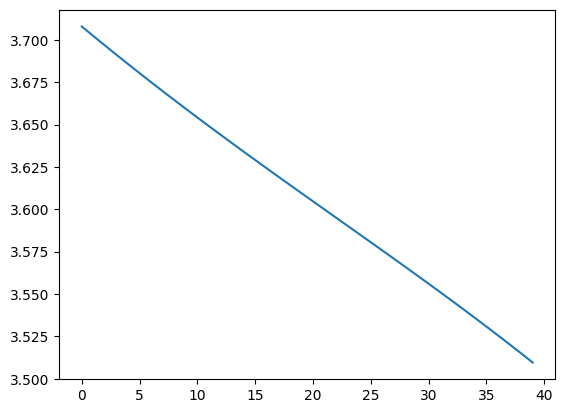

In [48]:
# Your plot code here
import matplotlib.pyplot as plt

plt.plot(losses)

In [63]:
import torch.nn.functional as F
import numpy as np


MAX_LENGTH = 300


def generate_sample(char_rnn, seed_phrase=' Hello', max_length=MAX_LENGTH, temperature=1.0):
    '''
    ### Disclaimer: this is an example function for text generation.
    ### You can either adapt it in your code or create your own function
    
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs, 
        smaller temperature converges to the single most likely output.
        
    Be careful with the model output. This model waits logits (not probabilities/log-probabilities)
    of the next symbol.
    '''
    seed_phrase = seed_phrase.lower()
    x_sequence = torch.tensor([token_to_idx[token] for token in seed_phrase]).unsqueeze(1)
    hid_state = char_rnn.initial_state(batch_size=1)
    
    #feed the seed phrase, if any
    for i in range(len(seed_phrase) - 1):
        print(x_sequence.shape, hid_state.shape)
        out, hid_state = char_rnn(x_sequence, hid_state)
    
    #start generating
    for _ in range(max_length - len(seed_phrase)):
        print(x_sequence.shape, x_sequence, hid_state.shape)
        out, hid_state = char_rnn(x_sequence, hid_state)
        # Be really careful here with the model output
        p_next = F.softmax(out / temperature, dim=-1).data.numpy()[0]
        
        # sample next token and push it back into x_sequence
        print(p_next.shape, len(tokens))
        next_ix = np.random.choice(len(tokens), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
        print(x_sequence.shape, next_ix.shape)
        x_sequence = torch.cat([x_sequence, next_ix], dim=1)
        
    return ''.join([tokens[ix] for ix in x_sequence.data.numpy()[0]])

In [64]:
# An example of generated text.
# print(generate_text(length=500, temperature=0.2))
generated_text = generate_sample(model)

torch.Size([6, 1]) torch.Size([1, 1, 10])
torch.Size([6, 1]) torch.Size([1, 1, 10])
torch.Size([6, 1]) torch.Size([1, 1, 10])
torch.Size([6, 1]) torch.Size([1, 1, 10])
torch.Size([6, 1]) torch.Size([1, 1, 10])
torch.Size([6, 1]) tensor([[ 1],
        [19],
        [16],
        [23],
        [23],
        [26]]) torch.Size([1, 1, 10])
(1, 38) 38


ValueError: 'p' must be 1-dimensional

### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [46]:
# Your beautiful code here

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [47]:
# Text generation with different temperature values here

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [4]:
# Saving and loading code here

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)